# Notebook 02 — Arbitrage-Free IV Surface Completion

Takes a sparse observed IV surface (missing strikes / maturities),
fits SVI slices, enforces calendar-spread and butterfly no-arbitrage constraints,
and produces a dense 8×11 surface suitable for calibration.

**Runtime estimate:** 1–3 min

In [1]:
import os, sys
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "src") if os.path.basename(os.getcwd()) == "notebooks"
                else os.path.join(os.getcwd(), "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import torch

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 11,
    "font.family": "serif",
})
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

from market.spx_data import T_GRID, K_GRID, download_spx_chain, clean_chain, to_iv_surface
from arbitrage.surface_completion import (
    complete_surface, check_calendar_spread, check_butterfly,
    make_arbitrage_free, fit_svi_slice,
)
from datetime import date


Device: cuda


## 1. Build a Realistic Sparse Surface

We take the 2024-01-02 SPX surface and blank out 40% of quotes at random,
simulating a realistic sparse options chain.

In [2]:
S0, R, Q = 4742.0, 0.053, 0.016   # SPX spot, risk-free rate, div yield 2024-01-02
rng = np.random.default_rng(0)
df_raw   = download_spx_chain(date(2024, 1, 2), cache=True)
df_clean = clean_chain(df_raw)
full_iv  = to_iv_surface(df_clean, S0, R, Q)   # (8, 11) ground truth

sparse_iv = full_iv.copy().astype(float)
mask = rng.random(sparse_iv.shape) < 0.40   # blank 40% of cells
sparse_iv[mask] = np.nan

n_observed = int((~mask).sum())
print(f"Observed cells : {n_observed} / {sparse_iv.size}")
print(f"Missing cells  : {mask.sum()} / {sparse_iv.size}")


Observed cells : 57 / 88
Missing cells  : 31 / 88


## 2. Complete the Surface

In [3]:
dense_iv = complete_surface(sparse_iv, mask, T_GRID, K_GRID)
print("Dense surface shape:", dense_iv.shape)
print("Any NaN remaining?  ", np.isnan(dense_iv).any())

# Enforce arbitrage constraints
af_iv = make_arbitrage_free(dense_iv, T_GRID, K_GRID, S=1.0)
print("Max butterfly violation (after):",
      np.abs(np.diff(np.diff(af_iv, axis=1), axis=1)).max() * 1e4, "bps²")


Dense surface shape: (8, 11)
Any NaN remaining?   False
Max butterfly violation (after): 0.0 bps²


## 3. Check No-Arbitrage Conditions

In [4]:
cal_viol_before = check_calendar_spread(dense_iv, T_GRID)
cal_viol_after  = check_calendar_spread(af_iv,    T_GRID)
but_viol_before = check_butterfly(dense_iv, K_GRID, T_GRID)
but_viol_after  = check_butterfly(af_iv,    K_GRID, T_GRID)

print(f"Calendar violations  — before: {(cal_viol_before > 0).sum()} cells  after: {(cal_viol_after > 0).sum()} cells")
print(f"Butterfly violations — before: {(but_viol_before > 0).sum()} cells  after: {(but_viol_after > 0).sum()} cells")


Calendar violations  — before: 0 cells  after: 0 cells
Butterfly violations — before: 0 cells  after: 0 cells


## 4. Visualise: Sparse vs Completed vs Ground Truth

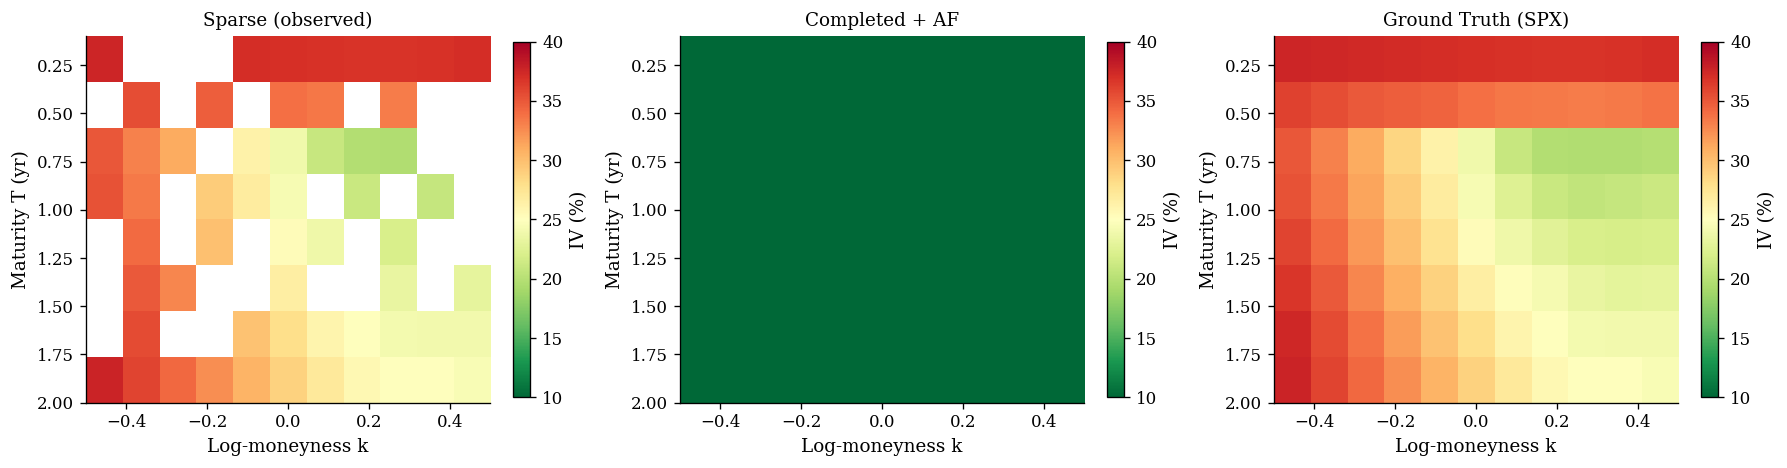

In [5]:
titles = ["Sparse (observed)", "Completed + AF", "Ground Truth (SPX)"]
surfaces = [sparse_iv, af_iv, full_iv]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
vmin, vmax = 0.10, 0.40
for ax, iv, title in zip(axes, surfaces, titles):
    im = ax.imshow(iv * 100, aspect="auto", cmap="RdYlGn_r",
                   vmin=vmin*100, vmax=vmax*100,
                   extent=[K_GRID[0], K_GRID[-1], T_GRID[-1], T_GRID[0]])
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Log-moneyness k")
    ax.set_ylabel("Maturity T (yr)")
    plt.colorbar(im, ax=ax, fraction=0.04, label="IV (%)")
plt.tight_layout()
plt.show()


## 5. Per-Slice SVI Fit

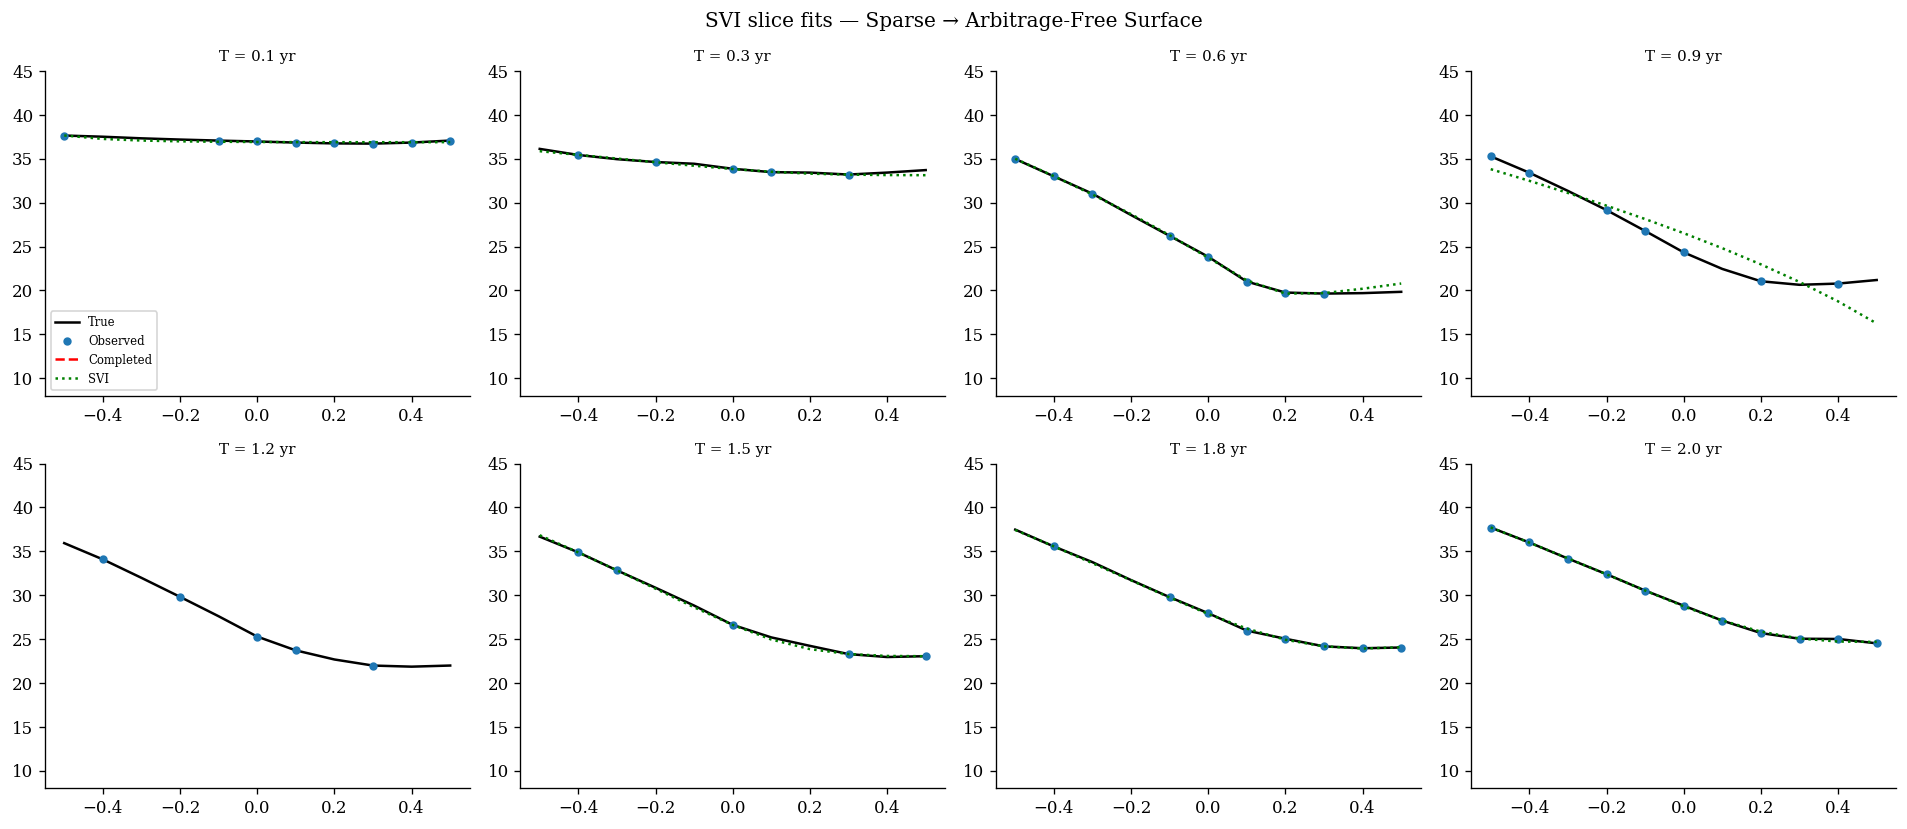

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, t_idx in zip(axes.flat, range(8)):
    T   = T_GRID[t_idx]
    k   = K_GRID
    obs = sparse_iv[t_idx]
    mask_t = ~np.isnan(obs)
    svi = fit_svi_slice(k[mask_t], obs[mask_t]**2 * T) if mask_t.sum() >= 3 else None

    ax.plot(k, full_iv[t_idx]*100,  "k-",  lw=1.5, label="True")
    ax.plot(k[mask_t], obs[mask_t]*100, "o", ms=4, label="Observed")
    ax.plot(k, af_iv[t_idx]*100,   "r--", lw=1.5, label="Completed")
    if svi:
        w = svi["a"] + svi["b"]*(svi["rho"]*(k-svi["m"]) +
            np.sqrt((k-svi["m"])**2 + svi["sigma"]**2))
        ax.plot(k, np.sqrt(np.maximum(w,0)/T)*100, "g:", lw=1.5, label="SVI")
    ax.set_title(f"T = {T:.1f} yr", fontsize=9)
    ax.set_ylim(8, 45)
    if t_idx == 0:
        ax.legend(fontsize=7)
plt.suptitle("SVI slice fits — Sparse → Arbitrage-Free Surface")
plt.tight_layout()
plt.show()
